In [ ]:
import serial
import matplotlib.pyplot as plt



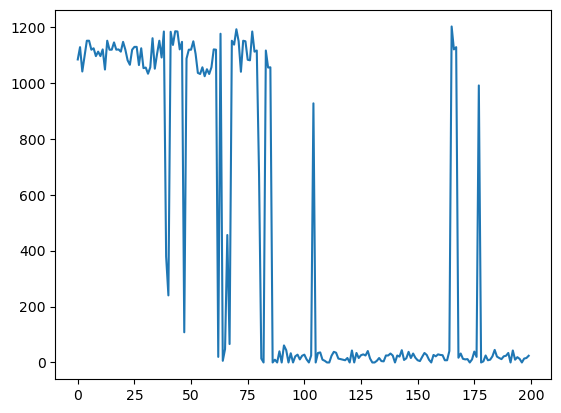

In [19]:
# FSR/Flex capture

ser = serial.Serial('COM7', 115200, timeout=1)

data = []
i = 0
while i < 200:
    line = ser.readline().decode('utf-8').strip()
    
    if line:
        data.append(int(line))
        i += 1

plt.plot(data)

ser.close()

In [65]:
# IMU Capture

CAPTURE_SECONDS = 15

ser = serial.Serial('COM7', 115200, timeout=1)

with open("imu.txt", "w") as file:
    data = []
    i = 0
    while i < CAPTURE_SECONDS * 20:
        line = ser.readline().decode('utf-8').strip()
        
        if line:            
            file.write(line + '\n')
            i += 1

file.close()
ser.close()

Text(0.5, 1.0, 'Gyro (z)')

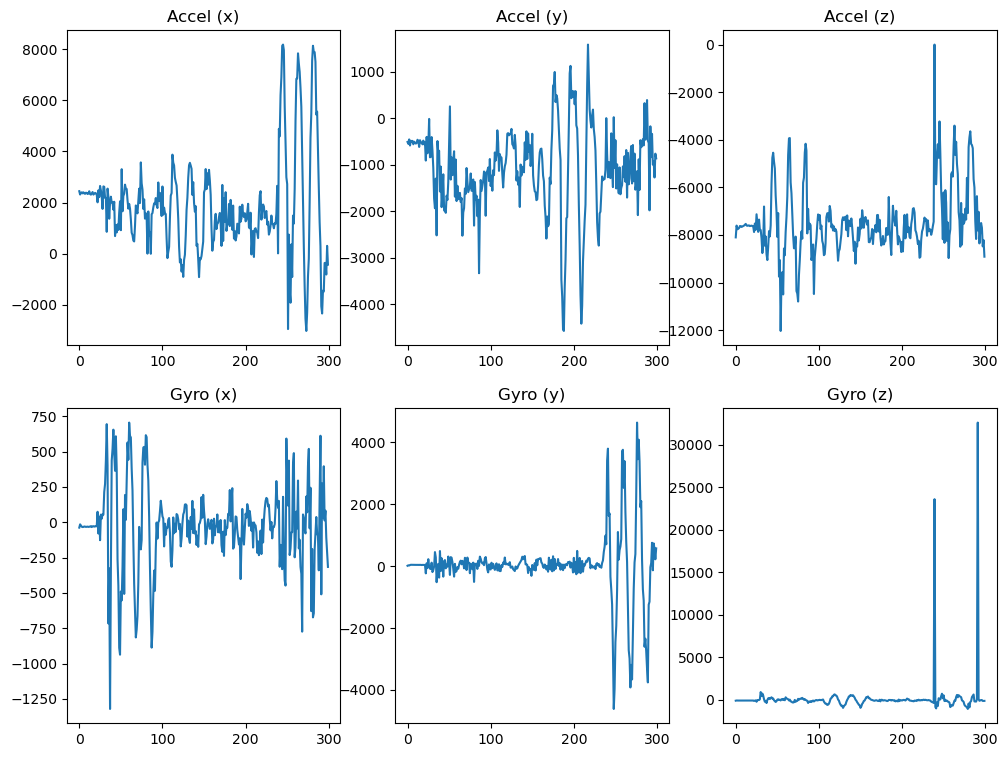

In [66]:
# IMU Visualization

# Parse data
ax = []
ay = []
az = []
gx = []
gy = []
gz = []
with open("imu.txt", 'r') as file:
    for line in file:
        line = line.strip()
        vals = line.split(' ')

        ax.append(int(vals[0]))
        ay.append(int(vals[1]))
        az.append(int(vals[2]))
        gx.append(int(vals[3]))
        gy.append(int(vals[4]))
        gz.append(int(vals[5]))

file.close()

plt.figure(figsize=(12, 9))
plt.subplot(2, 3, 1)
plt.plot(ax)
plt.title("Accel (x)")
plt.subplot(2, 3, 2)
plt.plot(ay)
plt.title("Accel (y)")
plt.subplot(2, 3, 3)
plt.plot(az)
plt.title("Accel (z)")
plt.subplot(2, 3, 4)
plt.plot(gx)
plt.title("Gyro (x)")
plt.subplot(2, 3, 5)
plt.plot(gy)
plt.title("Gyro (y)")
plt.subplot(2, 3, 6)
plt.plot(gz)
plt.title("Gyro (z)")

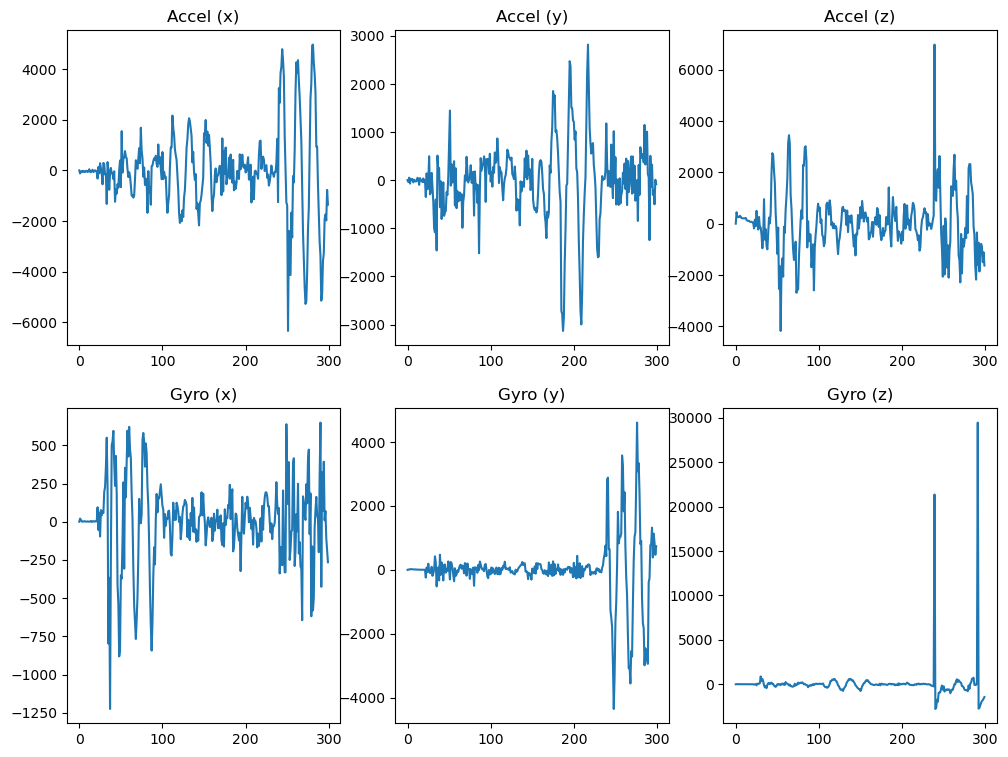

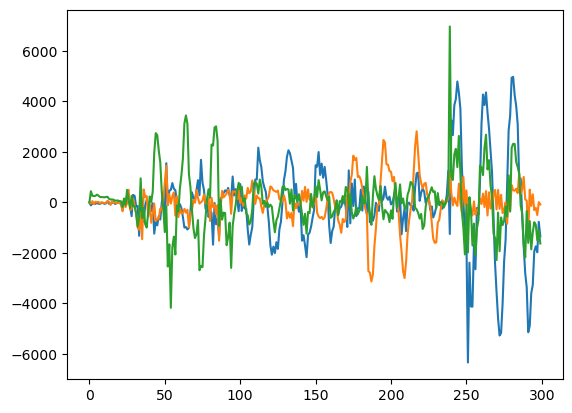

In [69]:
def HPF(signal, alpha = 0.9):
    hp = 0
    prev = signal[0]
    out = []
    
    for x in signal:
        hp = alpha * (hp + x - prev)
        prev = x
        out.append(hp)

    return out

ax_hp = HPF(ax)
ay_hp = HPF(ay)
az_hp = HPF(az)
gx_hp = HPF(gx)
gy_hp = HPF(gy)
gz_hp = HPF(gz)

plt.figure(figsize=(12, 9))
plt.subplot(2, 3, 1)
plt.plot(ax_hp)
plt.title("Accel (x)")
plt.subplot(2, 3, 2)
plt.plot(ay_hp)
plt.title("Accel (y)")
plt.subplot(2, 3, 3)
plt.plot(az_hp)
plt.title("Accel (z)")
plt.subplot(2, 3, 4)
plt.plot(gx_hp)
plt.title("Gyro (x)")
plt.subplot(2, 3, 5)
plt.plot(gy_hp)
plt.title("Gyro (y)")
plt.subplot(2, 3, 6)
plt.plot(gz_hp)
plt.title("Gyro (z)")

plt.figure()
plt.plot(ax_hp)
plt.plot(ay_hp)
plt.plot(az_hp)

Text(0.5, 1.0, 'Velocity (y)')

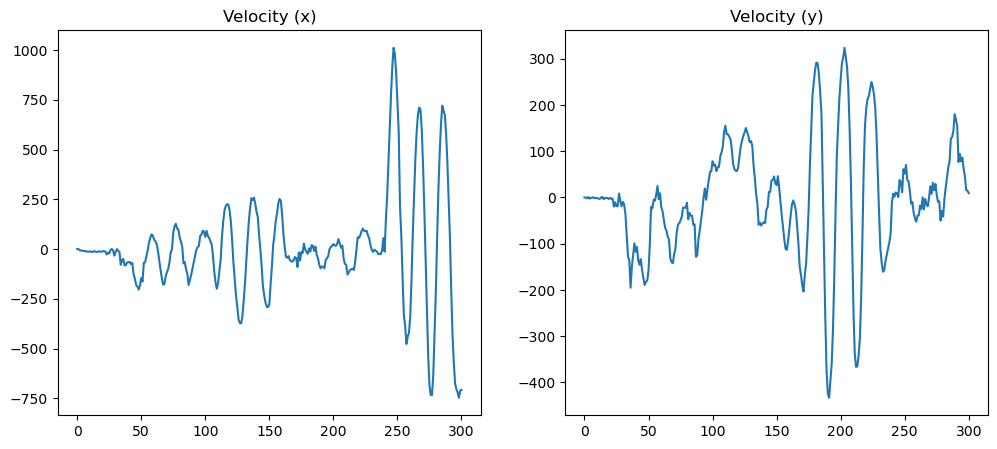

In [77]:
# Velocity tracking

drag = 0.9
dt = 0.05

vx = [0]
vy = [0]

v = 0
for a in ax_hp:
    v = drag * v + a * dt
    vx.append(v)

v = 0
for a in ay_hp:
    v = drag * v + a * dt
    vy.append(v)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(vx)
plt.title("Velocity (x)")
plt.subplot(1, 2, 2)
plt.plot(vy)
plt.title("Velocity (y)")